<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula08a_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Forecasting

In [1]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-05-18 23:24:06--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.253.143, 52.216.57.0, 16.15.254.141, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.253.143|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  20.8MB/s    in 0.6s    

2026-05-18 23:24:07 (20.8 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [2]:
import os
from pprint import pprint
fname = os.path.join('jena_climate_2009_2016.csv')

with open(fname) as f:
    data = f.read()
lines = data.split('\n')
header = lines[0].split(',')
lines = lines[1:]
pprint(header)
print(len(lines))

['"Date Time"',
 '"p (mbar)"',
 '"T (degC)"',
 '"Tpot (K)"',
 '"Tdew (degC)"',
 '"rh (%)"',
 '"VPmax (mbar)"',
 '"VPact (mbar)"',
 '"VPdef (mbar)"',
 '"sh (g/kg)"',
 '"H2OC (mmol/mol)"',
 '"rho (g/m**3)"',
 '"wv (m/s)"',
 '"max. wv (m/s)"',
 '"wd (deg)"']
420451


In [3]:
print(f"{len(lines)/6} horas")
print(f"{len(lines)/(6*24)} dias")
print(f"{len(lines)/(6*24*365)} anos")

70075.16666666667 horas
2919.7986111111113 dias
7.9994482496194825 anos


In [4]:
import numpy as np
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(',')[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]
raw_data.shape

(420451, 14)

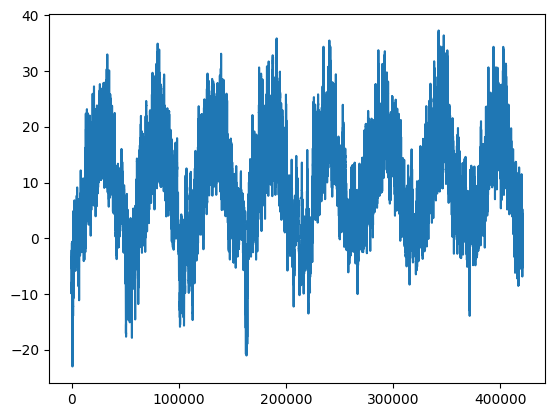

In [5]:
from matplotlib import pyplot as plt
plt.plot(range(len(temperature)), temperature)
plt.show()

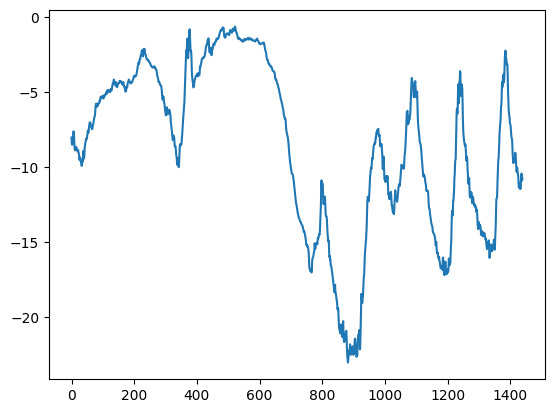

In [6]:
ten_days = 6*24*10
plt.plot(range(ten_days), temperature[:ten_days])
plt.show()

In [7]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print('num_train_samples:', num_train_samples)
print('num_val_samples:', num_val_samples)
print('num_test_samples:', num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [8]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [9]:
print(f"mean: {mean[1]}")
print(f"std: {std[1]}")

mean: 8.825903294089702
std: 8.770983608349871


In [10]:
import numpy as np
from tensorflow import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
    sampling_rate=1,
    shuffle=False
)
print(f"Int Sequence: {int_sequence}")
for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))
    print()

Int Sequence: [0 1 2 3 4 5 6 7 8 9]
[0, 1, 2] 3
[1, 2, 3] 4

[2, 3, 4] 5
[3, 4, 5] 6

[4, 5, 6] 7



In [11]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)
val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples+num_val_samples
)
test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples+num_val_samples
)

In [12]:
for samples, targets in train_dataset:
    print(f"samples shape: {samples.shape}")
    print(f"targets shape: {targets.shape}")
    break

samples shape: (256, 120, 14)
targets shape: (256,)


#baseline

In [13]:
def evaluate_naive_method(dataset):
    total_abs_err = 0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen
print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


# densely connected

In [14]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_dense.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model('jena_dense.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - loss: 14.1466 - mae: 2.8897 - val_loss: 10.4188 - val_mae: 2.5545
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 9.6919 - mae: 2.4421 - val_loss: 10.0933 - val_mae: 2.5125
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 8.8705 - mae: 2.3408 - val_loss: 10.2031 - val_mae: 2.5364
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 8.3715 - mae: 2.2780 - val_loss: 11.4610 - val_mae: 2.7086
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 7.9784 - mae: 2.2245 - val_loss: 11.3188 - val_mae: 2.6771
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 7.7030 - mae: 2.1831 - val_loss: 11.2830 - val_mae: 2.6808
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 7.4840 - mae: 2.1531 - val_loss: 10.4389 - val_mae: 2.5614
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 7.3049 - mae: 2.1283 - val_loss: 10.8744 - val_mae: 2.6176
Epoch 9/10
819/819 ━━━━━━━━━━━━

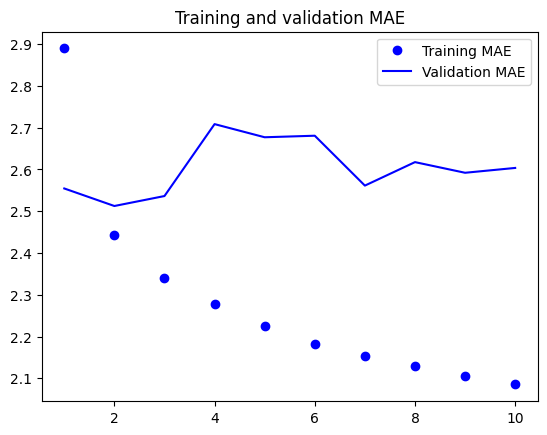

In [15]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

# 1D convolutional model

In [16]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation='relu')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_conv.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model('jena_conv.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - loss: 23.4119 - mae: 3.7387 - val_loss: 15.2694 - val_mae: 3.0750
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 14.9685 - mae: 3.0702 - val_loss: 15.2829 - val_mae: 3.0745
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 13.8498 - mae: 2.9468 - val_loss: 16.6172 - val_mae: 3.2413
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 13.0681 - mae: 2.8635 - val_loss: 14.0845 - val_mae: 2.9481
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - loss: 12.4923 - mae: 2.7990 - val_loss: 15.1021 - val_mae: 3.0629
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 12.0411 - mae: 2.7448 - val_loss: 14.2247 - val_mae: 2.9649
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 11.6713 - mae: 2.7021 - val_loss: 16.1311 - val_mae: 3.1565
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 11.3699 - mae: 2.6681 - val_loss: 14.6187 - val_mae: 3.0279
Epoch 9/10
819/819 ━━━━━

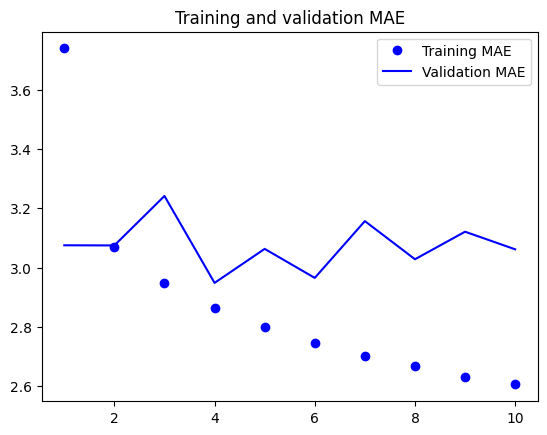

In [17]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

# Recurrent Network

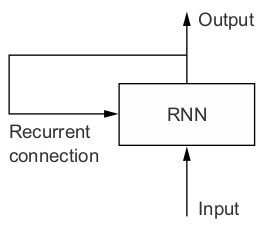

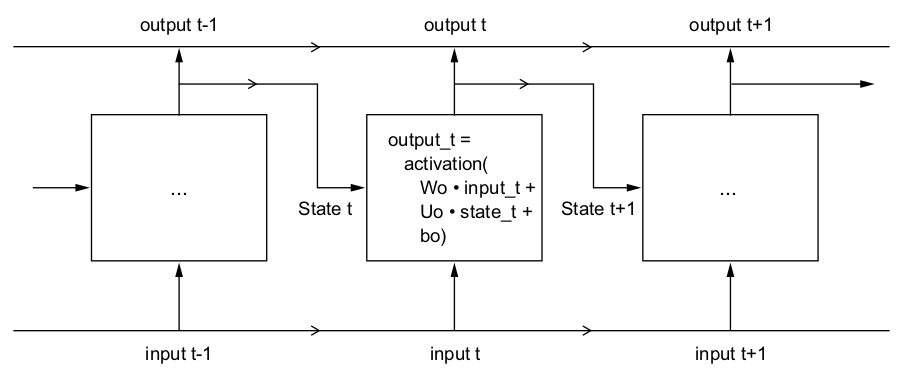

In [19]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 120, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 120, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,552 (6.06 KB)

 Trainable params: 1,552 (6.06 KB)

 Non-trainable params: 0 (0.00 B)

# LSTM

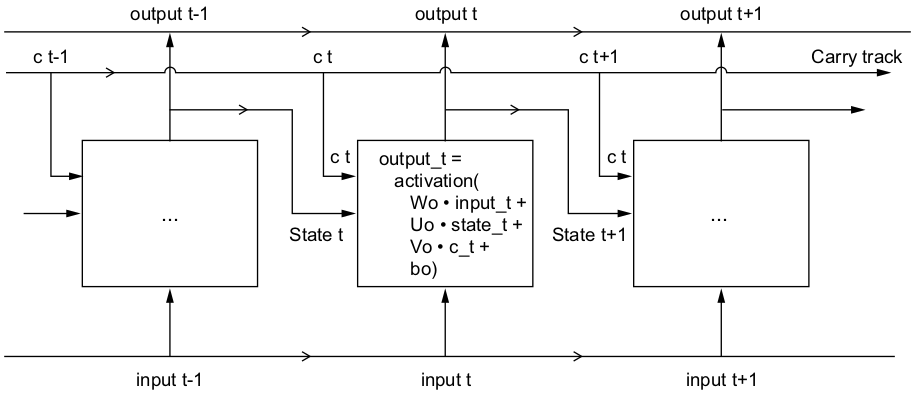

In [20]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_lstm.keras")
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - loss: 35.6088 - mae: 4.3081 - val_loss: 11.4310 - val_mae: 2.5930
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 10.6415 - mae: 2.5385 - val_loss: 9.9166 - val_mae: 2.4462
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 9.7955 - mae: 2.4373 - val_loss: 10.0229 - val_mae: 2.4519
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 9.3795 - mae: 2.3777 - val_loss: 10.0309 - val_mae: 2.4410
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 9.0232 - mae: 2.3294 - val_loss: 10.4514 - val_mae: 2.4575
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 97s 74ms/step - loss: 8.6825 - mae: 2.2862 - val_loss: 9.9629 - val_mae: 2.4538
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 8.3709 - mae: 2.2449 - val_loss: 10.3122 - val_mae: 2.4896
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 85s 63ms/step - loss: 8.1246 - mae: 2.2151 - val_loss: 10.7041 - val_mae: 2.5227
Epoch 9/10
819/819 ━━━━━━━━━━━━━

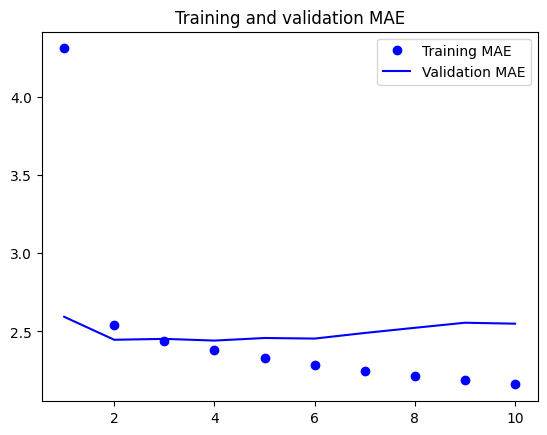

In [21]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

In [22]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_lstm.keras")
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - loss: 44.5506 - mae: 4.9755 - val_loss: 12.8827 - val_mae: 2.7257
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 19.7625 - mae: 3.4157 - val_loss: 9.9335 - val_mae: 2.4542
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - loss: 17.8784 - mae: 3.2512 - val_loss: 9.8043 - val_mae: 2.4509
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - loss: 17.0192 - mae: 3.1739 - val_loss: 9.5459 - val_mae: 2.4188
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 16.4197 - mae: 3.1190 - val_loss: 9.5127 - val_mae: 2.4079
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 15.9462 - mae: 3.0714 - val_loss: 9.7443 - val_mae: 2.4296
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 15.5915 - mae: 3.0384 - val_loss: 10.0102 - val_mae: 2.4667
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 15.1538 - mae: 2.9988 - val_loss: 9.7229 - val_mae: 2.4314
Epoch 9/10
819/819 ━━━━━━━━━━━

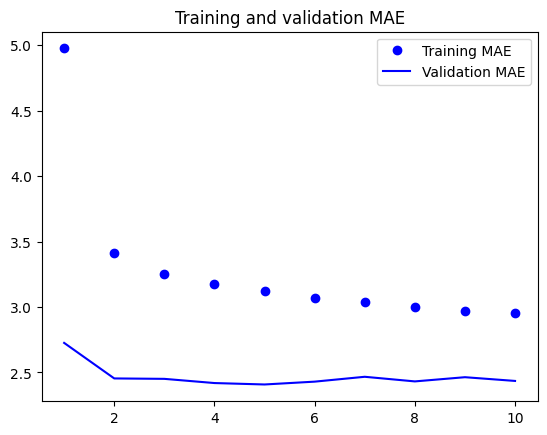

In [23]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

# Stacking recurrent layers

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("jena_stacked_gru.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_stacked_gru.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

# bidirectional LSTM

In [25]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("jena_bidirectional_lstm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_bidirectional_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - loss: 28.3724 - mae: 3.8224 - val_loss: 10.0098 - val_mae: 2.4394
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 9.6575 - mae: 2.4243 - val_loss: 9.8252 - val_mae: 2.4336
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 8.6287 - mae: 2.2870 - val_loss: 9.7901 - val_mae: 2.4139
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 7.9174 - mae: 2.1956 - val_loss: 10.0652 - val_mae: 2.4291
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 7.3707 - mae: 2.1234 - val_loss: 10.0892 - val_mae: 2.4454
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 6.9830 - mae: 2.0688 - val_loss: 10.6947 - val_mae: 2.5261
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 6.6597 - mae: 2.0203 - val_loss: 10.8545 - val_mae: 2.5413
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 6.4091 - mae: 1.9806 - val_loss: 11.0364 - val_mae: 2.5599
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

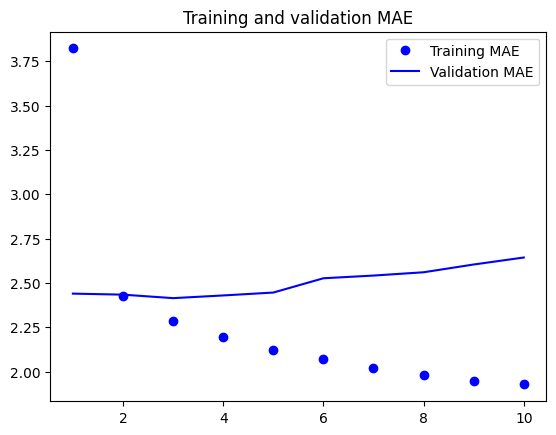

In [26]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()